Natural Language Processing (NLP) is a major subfield of AI that focuses on enabling computers to understand, analyze, and generate human language. Unlike structured data, natural language is highly complex and ambiguous. For example, the meaning of a word may change depending on context, and the interpretation of a sentence often relies on surrounding information. As a result, allowing machines to effectively process textual data has long been a central challenge in AI. With the rapid growth of the internet, massive amounts of textual data are generated every day through social media, news articles, reviews, and conversations. These data sources contain valuable information, making NLP widely used in applications such as search engines, machine translation, question answering, sentiment analysis, and conversational agents.

## **Core Components of NLP Systems**

### **Data**
Examples of the language phenomena we want our system to handle.

The amount of data required depends on the types of task, task complexity and model complexity: Sentiment(12000 sentences), Sentence Structure(40000 sentences), Translation(60 million words from each of 21 languages), Language modeling(1 million - 30 trillion+ words)

### **Model**
$$\text{score = (x, y)}$$
A function that maps (input, output) pairs to scores. In most tasks(supervised), model is the map relationship between the input(documnet) and output(label) from the data. There are four common types of **Model** in NLP System:

- **Rule-based Model**(1966-1980s): it relies on **manually designed linguistic rules** to process language. For example "If the review contains "good" return positive". Which has strong interpretability, but with non-extensible and high maintenance costs.
- **Statistical Model**(1990s): describe language phenomena using probabilistic models, for example: n-gram Language Model, Naive Bayes, Hidden Markov Model(HMM). These models estimate probabilities from data and were widely used in early NLP systems.
- **Classical Machine Learning**(1990s): it treats NLP as a **feature-based learning problem**. Text is first converted into features (e.g., Bag-of-Words or TF-IDF), and then a machine learning model is trained.For example: Logistic Regression, Linear Model, Support Vector Machine(SVM), Decison Tree. These models are efficient and often serve as strong baselines.
- **Neural Network Model**(2010s): it learns **distributed representations** of text and extract features automatically through multiple layers., like Feedforward Network, Recurrent Neural Network(RNN), Convolutional Neural Network (CNN), Long Short-Term Memory (LSTM). These models can capture complex patterns and contextual relationships in text.
- **Transformer-based Model**(2018-): modern NLP systems are largely based on **Transformer architectures**. Transformers convert text into vector representations and use **self-attention mechanisms** to model relationships between words in a sequence.  
Deep neural layers then learn contextual semantic representations, which can be used for prediction or text generation. For instances, Bidirectional Encoder Representations from Transformers(BERT), Generative Pre-trained Transformer(GPT).

### **Inference Method**
A way to make a prediction for an example given a **Model**. It finds an output that a model gives a high score too (not necessarily the highest scoring one and not necessarily the true best).
$$
y^* = \arg\max_{y} score(x, y)
$$
<details>
    
<summary>Simple approach</summary>
    
```python
best_score = -inf
best_label = None

for label in labels:
    score = model(x, label)
    if score > best_score:
        best_score = score
        best_label = label

return best_label
```
</details>

**Common Inference Algorithms**:

- **Greedy Search**: it selects the best option at each step. Fast and simple, but may miss the global optimum because it only considers local decisions.
- **Beam Search**: it keeps the top k candidates at each step, which produces better results than greedy search, but with higher computational cost.
- **A-star Search**: it is a heuristic search algorithm that explores the most promising paths first. It is useful when the search space is large but structured.
- **Dynamic Programming**(e.g. Viterbi Search): it is used when problems contain overlapping subproblems. It improves efficiency by avoiding repeated computation. 

### **Metric**
A function that gives a score to the output produced by a **Model** given some **Data**. It  gives a measurement of how good the output of your system is compared to the best answer. For evaluation metrics, please refer to Statistic/Modeling/Model Evaluation part

**Common Metric**:

- **0-1 Loss**: the simplest evaluation metric for classification. Very intuitive, directly reflects classification errors, but not continuous, differentiable, difficult to optimize using gradient-based methods. Therefore, 0-1 loss is mostly used for theoretical evaluation rather than training models. 
    - $L(y,f(x)) =\begin{cases} 0 & \text{if prediction is correct} \\ 1 & \text{otherwise}\end{cases}$
    - Correct prediction → loss = 0. Incorrect prediction → loss = 1.

- **Hinge Loss**($L = \max(0, 1 - y \cdot f(x))$, where: $y$ is the true label (usually $+1$ or $-1$), $f(x)$ is the model output): a prediction should not only be correct, but should also have a sufficient margin. Hinge loss is commonly used in **Support Vector Machines (SVM)**.
    - Confident correct prediction → loss = 0
    - Prediction near the boundary → small loss
    - Wrong prediction → large loss

- **Cross-Entropy Loss**($L = -\log p(y)$): is one of the **most widely used metrics in NLP**. If the model assigns high probability to the correct label, the loss will be small.
    - For multi-class classification:$L = -\sum_{i \in classes} y_i \log(p(y_i))$
    - where: $y_i$ is the true label indicator, $p(y_i)$ is the predicted probability

- **Squared Error**($L = (y - f(x))^2$): it measures the squared difference between the true value and the predicted value. The larger the difference between prediction and true value,the  larger the loss.

### **Learning Method**
A way to update a **Model** given **Data** a **Metric** and an **Inference Method**. It is an algorithm that uses data and a metric to see what mistakes your system makes and then updates the model to reduce those mistakes. The learning algorithm updates the parameters iteratively in order to reduce the loss. Formally, the learning process can be written as: $\min_{\theta} L(\theta)$, where: $\theta$ represents the model parameters, $L(\theta)$ is the loss function

**Learning Process**: Input data -> Model prediction -> Compute loss -> Updata parametters -> Repeat

**Common Learning Method**(Optimizer ):

- **Gradient Descent**($\theta = \theta - \eta \nabla L(\theta)$): it computes gradients using the **entire dataset** and updates parameters in the direction that reduces the loss. Because it uses all data for each update, it provides stable and accurate gradient estimates but becomes very slow when datasets are large. Its main advantages are simplicity and stable convergence, making it useful for theoretical analysis and small datasets. However, it is computationally expensive and impractical for large-scale deep learning.

- **Stochastic Gradient Descent(SGD, $\theta = \theta - \eta \nabla L_i(\theta)$, where $L_i$ is the loss for one sample or mini-batch.)**: it improves efficiency by updating parameters using **one sample or a small mini-batch** at a time instead of the entire dataset. This greatly speeds up training and allows models to scale to large datasets. The tradeoff is that the updates are noisy and can oscillate around the optimal solution. SGD works well in large-scale neural network training but may require careful tuning of the learning rate.

- **Adam**(Adaptive Moment Estimation): Adam combines the ideas of **Momentum and RMSProp** by maintaining both the first moment (mean of gradients) and second moment (variance of gradients). This allows it to adapt learning rates automatically while also smoothing gradient updates. Adam is one of the most widely used optimizers in deep learning and NLP because it converges quickly and requires minimal tuning. However, it can sometimes produce slightly worse generalization than SGD in some tasks.

    - First moment: $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$
    - Second moment: $v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$
    - Parameter update: $\theta = \theta - \eta \frac{m_t}{\sqrt{v_t} + \epsilon}$

<details>
<summary>NLP System Example</summary>

```python
import re
import random
from collections import Counter
from typing import List, Tuple, Dict

# ============================================================
# 1. DATA
# ============================================================
# Data = examples of the language phenomena we want the system to handle
# 这里我们用一个小型情感分类数据集，每条数据是 (text, label)
# label: 1 = positive, 0 = negative
# ============================================================

dataset: List[Tuple[str, int]] = [
    ("this movie is fantastic", 1),
    ("i love this film", 1),
    ("what a great and wonderful story", 1),
    ("this was an amazing performance", 1),
    ("i really enjoyed this movie", 1),
    ("the acting was brilliant", 1),
    ("this film is very good", 1),
    ("absolutely loved the ending", 1),
    ("the movie was inspiring and touching", 1),
    ("a delightful and enjoyable film", 1),

    ("this movie is terrible", 0),
    ("i hate this film", 0),
    ("what a boring and awful story", 0),
    ("this was a horrible performance", 0),
    ("i really disliked this movie", 0),
    ("the acting was terrible", 0),
    ("this film is very bad", 0),
    ("absolutely hated the ending", 0),
    ("the movie was dull and disappointing", 0),
    ("a painful and unpleasant film", 0),
]

random.seed(42)
random.shuffle(dataset)

split = int(0.8 * len(dataset))
train_data = dataset[:split]
test_data = dataset[split:]


# ============================================================
# Text preprocessing (still part of DATA representation)
# ============================================================
# 这里做最简单的 tokenization：小写 + 按单词切分
# ============================================================

def tokenize(text: str) -> List[str]:
    return re.findall(r"\b\w+\b", text.lower())


def build_vocab(data: List[Tuple[str, int]]) -> Dict[str, int]:
    vocab = {}
    for text, _ in data:
        for token in tokenize(text):
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab


vocab = build_vocab(train_data)


def vectorize(text: str, vocab: Dict[str, int]) -> List[float]:
    """
    Bag-of-Words representation:
    text -> feature vector
    """
    vec = [0.0] * len(vocab)
    counts = Counter(tokenize(text))
    for token, count in counts.items():
        if token in vocab:
            vec[vocab[token]] = float(count)
    return vec


X_train = [vectorize(text, vocab) for text, _ in train_data]
y_train = [label for _, label in train_data]

X_test = [vectorize(text, vocab) for text, _ in test_data]
y_test = [label for _, label in test_data]


# ============================================================
# 2. MODEL
# ============================================================
# Model = a function that maps (input, output) pairs to scores
# 这里我们用最简单的线性模型：
# score(x) = w · x + b
# 如果 score >= 0，倾向 positive
# 如果 score < 0，倾向 negative
# ============================================================

class LinearSentimentModel:
    def __init__(self, num_features: int):
        self.weights = [0.0] * num_features
        self.bias = 0.0

    def score(self, x: List[float]) -> float:
        return sum(w * xi for w, xi in zip(self.weights, x)) + self.bias


# ============================================================
# 3. INFERENCE METHOD
# ============================================================
# Inference Method = a way to make a prediction given a model
# 这里的推理规则是：
# pred = 1 if score >= 0 else 0
# ============================================================

def predict(model: LinearSentimentModel, x: List[float]) -> int:
    score = model.score(x)
    return 1 if score >= 0 else 0


# ============================================================
# 4. LEARNING METHOD
# ============================================================
# Learning Method = a way to update the model using data + errors
# 这里我们实现 Perceptron Learning：
#
# 如果预测正确，不更新
# 如果预测错误：
#   positive(1) but predicted negative(0): w = w + x, b = b + 1
#   negative(0) but predicted positive(1): w = w - x, b = b - 1
#
# 为了方便，我们把 label 转成:
#   positive -> +1
#   negative -> -1
#
# then:
#   if y * score <= 0:
#       w = w + y * x
#       b = b + y
# ============================================================

def train_perceptron(
    model: LinearSentimentModel,
    X: List[List[float]],
    y: List[int],
    epochs: int = 10
) -> None:
    """
    Train using the perceptron update rule.
    """
    y_signed = [1 if label == 1 else -1 for label in y]

    for epoch in range(epochs):
        mistakes = 0
        for x, y_true in zip(X, y_signed):
            score = model.score(x)

            # mistake or boundary case
            if y_true * score <= 0:
                mistakes += 1
                for i in range(len(model.weights)):
                    model.weights[i] += y_true * x[i]
                model.bias += y_true

        print(f"Epoch {epoch + 1}: mistakes = {mistakes}")


# ============================================================
# 5. METRIC
# ============================================================
# Metric = a function that measures how good predictions are
# 这里我们用 Accuracy
# ============================================================

def accuracy(model: LinearSentimentModel, X: List[List[float]], y: List[int]) -> float:
    correct = 0
    for x, y_true in zip(X, y):
        y_pred = predict(model, x)
        if y_pred == y_true:
            correct += 1
    return correct / len(y)


# ============================================================
# Run the full NLP system
# ============================================================

model = LinearSentimentModel(num_features=len(vocab))

print("Before training:")
print("Train Accuracy:", accuracy(model, X_train, y_train))
print("Test Accuracy :", accuracy(model, X_test, y_test))

print("\nTraining...")
train_perceptron(model, X_train, y_train, epochs=10)

print("\nAfter training:")
print("Train Accuracy:", accuracy(model, X_train, y_train))
print("Test Accuracy :", accuracy(model, X_test, y_test))


# ============================================================
# Demo predictions
# ============================================================

demo_texts = [
    "this movie was wonderful",
    "i hated this boring film",
    "the acting was good",
    "the ending was awful",
    "what an inspiring story",
]

print("\nDemo predictions:")
for text in demo_texts:
    x = vectorize(text, vocab)
    score = model.score(x)
    label = predict(model, x)
    sentiment = "positive" if label == 1 else "negative"
    print(f"Text: {text}")
    print(f"Score: {score:.2f}, Prediction: {sentiment}")
    print("-" * 50)
```
</details>

## **Baseline in NLP**
The baseline in NLP System is a simple, foundational model or heuristic used as a point of reference to evaluate the performance of more complex, advanced models (like BERT or GPT). It sets a "floor" of performance that any new, sophisticated approach must surpass to justify its added complexity, computational cost, and time.

**Key Purposes of a Baseline in NLP**:

- **Benchmarking**: baselines act as a yardstick, allowing practitioners to quantify improvements. If a new model does not surpass the baseline (e.g., TfidfVectorizer with Logistic Regression), it is a signal to revisit the problem definition or data quality.
- **Sanity Check**: baselines help identify bugs in the data pipeline or feature engineering. A "simple" model should perform reasonably; if it doesn't, something is likely wrong with the approach.
- **Performance Metrics**: baselines show how hard a problem actually is. For example, in highly imbalanced datasets, a simple "majority class" baseline can reveal whether an advanced model is truly learning or just predicting the most frequent label.

**Common Types of Baselines in NLP**(By complexity level):

- **Naive Baseline**: it is the simplest reference model in NLP that makes predictions without using any real textual understanding, usually relying only on dataset statistics such as label frequency. Its main advantage is that it is extremely easy to implement, requires almost no computational resources, and provides a minimum performance reference that helps detect dataset imbalance or trivial solutions. However, its major disadvantage is that it completely ignores the content of the text and therefore cannot capture any linguistic patterns or semantic information. Naive baselines are mainly used as a **sanity check** in classification tasks to ensure that more sophisticated models actually learn meaningful patterns rather than simply exploiting label distribution.
    - **Typical Methods**:
        - **Majority Class Baseline** – always predict the most frequent label.
        - **Random Prediction** – randomly assign labels, either uniformly or according to label distribution.

- **Heuristic Baseline**: it uses simple linguistic rules, dictionaries, or manually designed patterns to generate predictions. Instead of learning from large datasets, it relies on human intuition about language, such as keywords or lexical cues. The main advantages of heuristic systems are their interpretability, simplicity, and ability to work even when training data is limited. However, they typically suffer from poor generalization, difficulty scaling to large domains, and an inability to capture complex semantic or contextual relationships. Heuristic baselines are often used in early-stage prototypes, low-resource NLP tasks, and rule-driven applications such as simple sentiment analysis or information extraction systems.
    - **Typical Methods**:
        - **Keyword Rules** – detect specific words to determine labels.
        - **Lexicon-based Methods** – compute scores using sentiment or domain dictionaries.
        - **Pattern Matching Rules** – apply linguistic patterns such as capitalization or suffix rules.


- **Classical Machine Learning Baseline**: it represents text using statistical features and apply traditional machine learning algorithms to learn prediction functions. These models typically rely on vectorized text representations such as bag-of-words or TF-IDF and use linear classifiers to map features to outputs. Their advantages include simplicity, strong performance on many medium-scale tasks, relatively low computational cost, and good interpretability compared with deep neural networks. However, they often struggle with capturing deep semantic meaning, long-range dependencies, and contextual word interactions. Classical ML baselines are widely used in tasks such as sentiment analysis, spam detection, topic classification, and other text classification problems.
    - **Typical Methods**:
        - **Bag-of-Words (BoW)** – represent documents as word frequency vectors.
        - **TF-IDF Features** – weight words based on importance across documents.
        - **Logistic Regression** – a common linear classifier for text classification.
        - **Linear SVM** – a strong baseline for many NLP classification tasks.
        - **Naive Bayes** – a probabilistic classifier effective for text data.


- **Simple Neural Baseline**: it introduces neural networks and dense word representations to model language patterns. Instead of relying on sparse statistical features, these models learn distributed representations (embeddings) and capture contextual relationships between words through neural architectures. Their advantages include the ability to learn richer semantic representations, automatically extract useful features, and model sequential dependencies in text. However, they require more computational resources, larger datasets for effective training, and are often less interpretable than classical ML models. Simple neural baselines are commonly used for sentence classification, sequence labeling, semantic similarity tasks, and other problems where contextual information is important.

    - **Typical Methods**：
        - **Average Word Embeddings** – represent sentences by averaging word vectors.
        - **CNN for Text** – capture local n-gram patterns using convolution layers.
        - **BiLSTM Models** – model sequential context using recurrent neural networks.


- **Pretrained Model Baseline**: it relies on large-scale pretrained language models that have already learned linguistic and semantic knowledge from massive corpora. These models are then fine-tuned for specific NLP tasks, enabling strong performance even with relatively small task-specific datasets. Their main advantages include powerful contextual understanding, strong transfer learning ability, and state-of-the-art performance on many NLP benchmarks. However, they typically require substantial computational resources, large memory capacity, and are harder to interpret compared with simpler models. Pretrained baselines are now widely used in modern NLP tasks including text classification, question answering, named entity recognition, summarization, and machine translation.

    **Typical Methods**:
    - **BERT + Classification Head** – Use a pretrained BERT model to encode the input text, then add a simple linear classifier on top of the `[CLS]` representation for prediction.
    - **RoBERTa Fine-tuning** – Fine-tune a pretrained RoBERTa model by attaching a task-specific output layer and training it on the target NLP task.
    - **T5 / GPT for Generation Tasks** – Use pretrained generative language models and fine-tune them so they generate task-specific outputs such as summaries, translations, or answers.

## **Text Representation**
### **Discrete Representation(Frequency Based)**

Discrete representations are one of the earliest approaches for representing text in NLP. They treat each word as a unique symbol and represent it using a vector based on its position in the vocabulary. These methods usually generate **high-dimensional sparse vectors**, meaning most values in the vector are zero. Although they are simple and interpretable, they cannot capture semantic similarities between words.

#### **One-Hot Encoding**

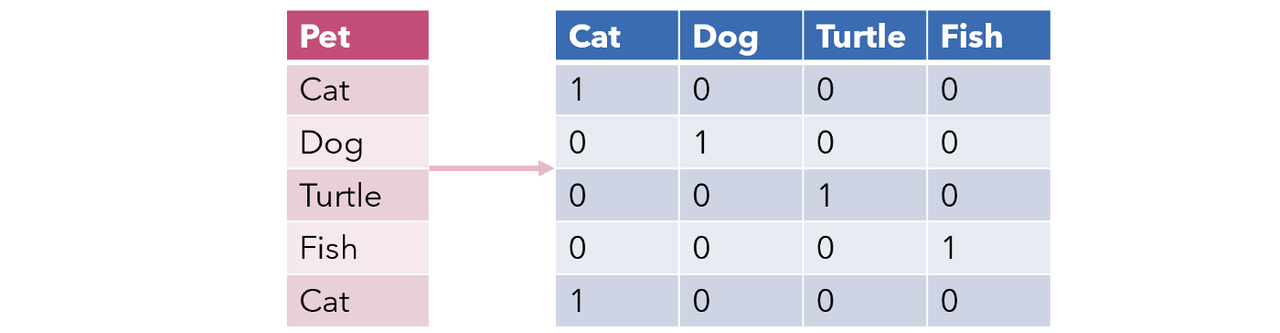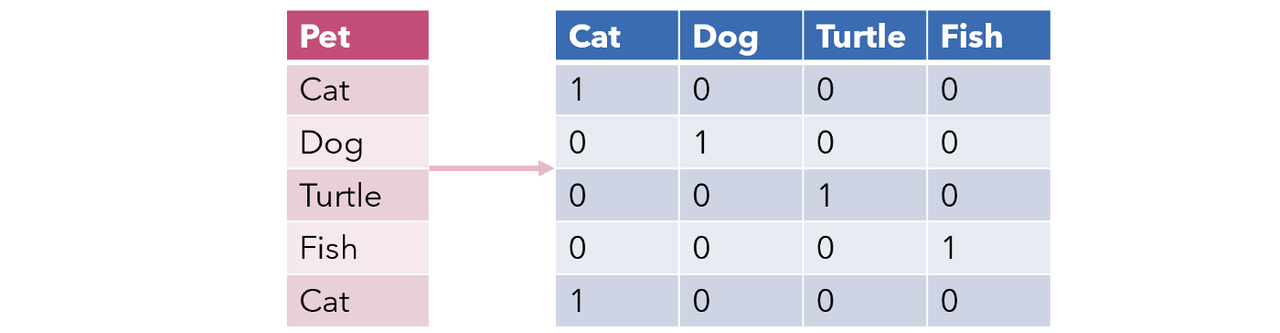

One-Hot Encoding is one of the simplest ways to represent words numerically in Natural Language Processing. The basic idea is to assign each word in the vocabulary a unique index, and represent the word as a vector where:

- one position is 1
- all other positions are 0
  
If the vocabulary size is $V$, each word is represented by a $V$-dimensional vector.

Limitation:

- High-dimensional vectors, Computationally expensive, infficient and Memory-intensive
- Does not capture Semantic Relationships/Similarity
- Restricted to the seen training vocabulary

<details>
<summary>Python Implementation</summary>

```python
def one_hot_encode(text):
    words = text.split() # Split the text by whitespace
    vocabulary = set(words) # Keep the elements unique in the set
    word_to_index = {word: i for i, word in enumerate(vocabulary)} # Assign index for each word in vocabulary, output will be like {word0 : 0, word1: 1, ...}
    one_hot_encoded = []
    for word in words: # For every word, create the vector with 0 and lenght of vocabulary firstly, then set the corresponding position to 1 according to the word index
        one_hot_vector = [0] * len(vocabulary) 
        one_hot_vector[word_to_index[word]] = 1
        one_hot_encoded.append(one_hot_vector)
    return one_hot_encoded, word_to_index, vocabulary
```
</details> 

<details>
<summary>Python scikit-learn Implementation</summary>
    
```python
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Example data
words = np.array(["cat", "dog", "fish", "cat"]).reshape(-1, 1)

# Create encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform
one_hot_vectors = encoder.fit_transform(words)

print("Vocabulary:", encoder.categories_)
print("One-hot vectors:\n", one_hot_vectors)
```
</details>

#### **Bag of Words (BoW)**
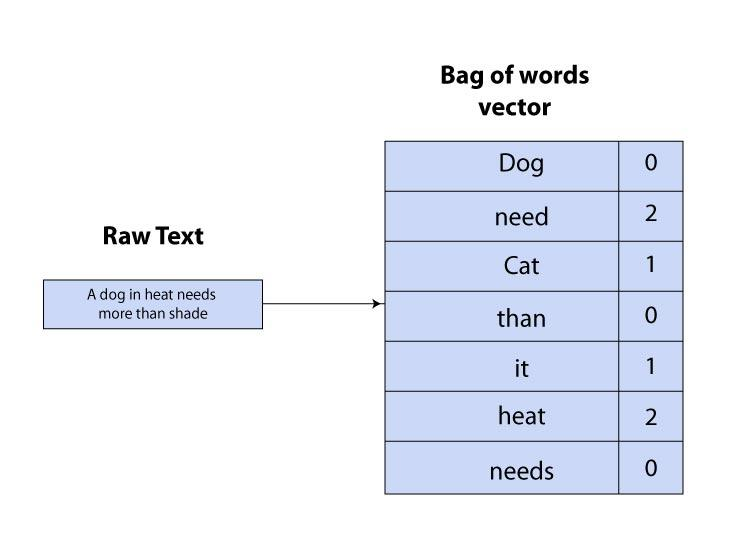

Bag of Words is a simple and widely used method for representing text as numerical vectors. The core idea is to represent a document based on **the frequency of words that appear in it**, without considering the order of the words.

In the Bag of Words model, a vocabulary is first constructed from all unique words in the corpus. Each document is then represented as a vector whose length equals the size of the vocabulary. Each element in the vector indicates **how many times a particular word appears in the document**.

Limitations:

- It ignores word order and grammar
- It **cannot capture semantic relationships** between words
- It will be very **hign-dimensinal** when the vocabulary is large

<details>
<summary>Python Implementation</summary>
    
```python
"""
Document
   ↓
Tokenization
   ↓
Count word frequency
   ↓
Map to vocabulary index
   ↓
Vector representation
"""
import numpy as np

# vocabulary (normally built from a corpus)
vocab = ["cat", "dog", "fish"]

# word -> index
word_to_index = {word: i for i, word in enumerate(vocab)}

def bow_encode(document):
    vector = np.zeros(len(vocab))
    
    words = document.split()
    
    for word in words:
        if word in word_to_index:
            vector[word_to_index[word]] += 1
    
    return vector

doc = "cat dog cat"

print(bow_encode(doc))
```
</details>

<details>
<summary>Python scikit-learn Implementation</summary>
    
```python
from sklearn.feature_extraction.text import CountVectorizer
documents = ["This is the first document.", "This document is the second document.", "And this is the third one.", "Is this the first document?"]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print("Bag-of-Words Matrix:")
print(X.toarray())
print("Vocabulary (Feature Names):", feature_names)
```
</details>

#### **TF-IDF**
$\text{TF-IDF: } w_{t,d} = tf_{t,d} \times idf_{t}$

TF-IDF (Term Frequency–Inverse Document Frequency) is a weighted text representation method **based on Bag of Words**. It measures not only how often a word appears in a document, but also how important that word is across the whole corpus.

The basic idea is that a word should receive a high weight if it appears frequently in the current document but rarely in other documents. This makes TF-IDF more informative than simple word counts, because common words across many documents are given lower importance. TF-IDF is widely used in text classification, information retrieval, keyword extraction, and document similarity tasks. However, like other discrete representations, it still produces sparse vectors and cannot capture semantic or contextual relationships between words.

**Term Frequency**:

- $\text{Raw TF: } TF(t,d) = \text{count}(t,d)$
- $\text{Normal TF: } TF(t,d) = \frac{\text{Number of times term t appears in document d}}{\text{Total number of terms in documnet d}}$
- $\text{Log TF: } tf_{t,d} =
\begin{cases}
1 + \log_{10}(\text{count}(t,d)) & \text{if } \text{count}(t,d) > 0 \\
0 & \text{otherwise}
\end{cases}$ 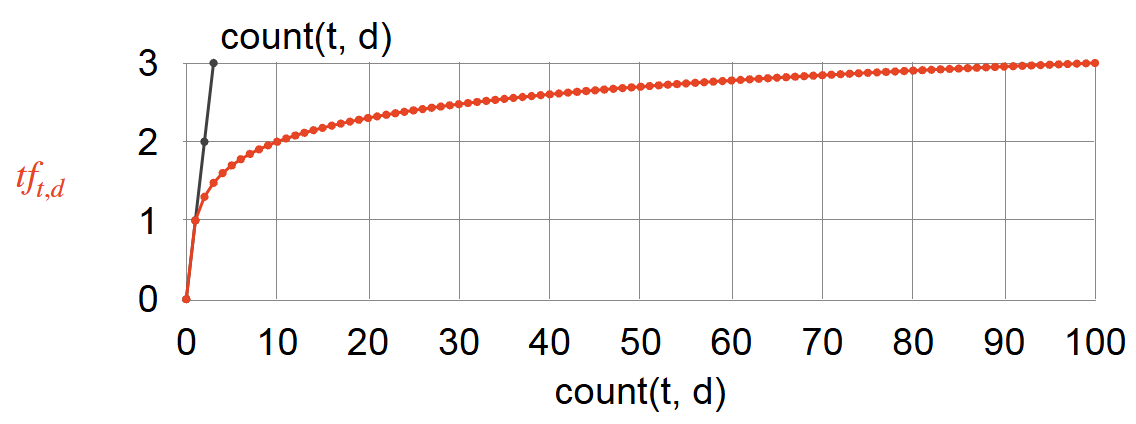

- $\text{Binary TF: } TF(t,d) = \begin{cases} 1 & t \in d \\ 0 & \text{otherwise} \end{cases}$
- $\text{Augmented TF: }TF(t,d) = 0.5 + 0.5 \frac{\text{count}(t,d)} {\max_{t'} \text{count}(t',d)}$

**Inverse Document Frequency**(N = number of documents, df(t) = how many documents token t occurs in):

- $\text{Raw IDF: } IDF(t,D) = \log \frac{\text{Total number of documents in corpus N}}{\text{Number of documnents containing term t}}$
$idf(t) = \log\left(\frac{N}{df_t} \right)$
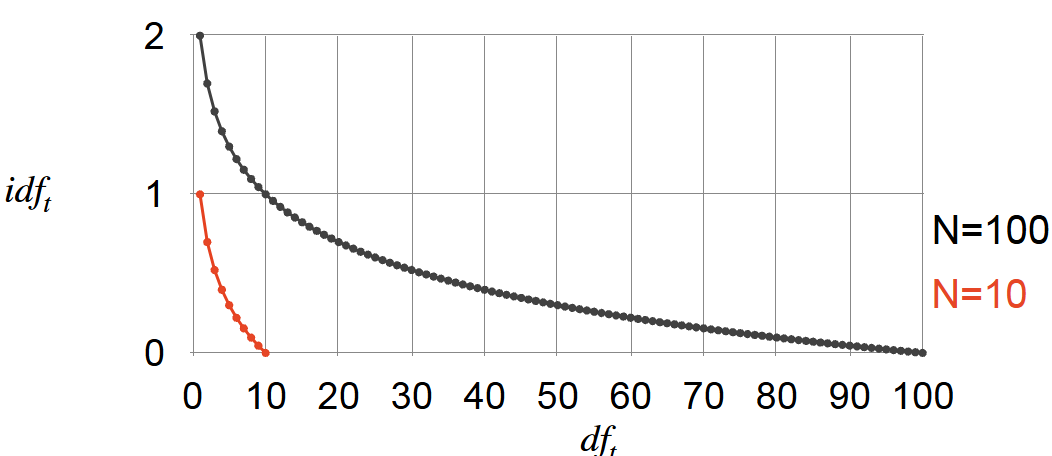
- $\text{Smoothed IDF: } idf(t) = \log \left(\frac{N}{1+df_t} \right) + 1$
- $\text{Probabilistic IDF: }idf(t) = \log\left(\frac{N - df_t}{df_t} \right)$
- $\text{Max IDF: }\log\left(\frac{\max_{t' \in D} d_{t'}}{1 + d_t}\right)$

**Example**

Suppose we have the following corpus:

- D1: data science is fun
- D2: data science uses data
- D3: machine learning is fun

We want to compute the Log TF-IDF of the term $data$ in document $D2$.

The log-scaled term frequency is defined as:

$$
tf(t,d) =
\begin{cases}
1 + \log_{10}(count(t,d)) & \text{if } count(t,d) > 0 \\
0 & \text{otherwise}
\end{cases}
$$

Since $count(data, D2) = 2$,

$$
tf(data, D2) = 1 + \log_{10}(2) \approx 1.301
$$

The inverse document frequency is:

$$
idf(t) = \log_{10}\left(\frac{N}{df_t}\right)
$$

Here, $N = 3$ and $df_{data} = 2$, so:

$$
idf(data) = \log_{10}\left(\frac{3}{2}\right) \approx 0.176
$$

Therefore, the TF-IDF value is:

$$
tfidf(data, D2) = tf(data, D2) \times idf(data)
$$

$$
tfidf(data, D2) = 1.301 \times 0.176 \approx 0.229
$$

<details>
<summary>Python Implementation</summary>
    
```python
import math
from collections import Counter

def compute_tfidf(documents):
    """
    Compute TF-IDF vectors for a list of documents.
    
    Parameters:
        documents (list[str]): A list of input documents.
        
    Returns:
        tfidf_vectors (list[dict]): TF-IDF vector for each document.
        vocabulary (list[str]): Sorted list of all unique terms.
        idf (dict): IDF value for each term.
    """
    
    # Step 1: Tokenize documents
    tokenized_docs = [doc.lower().split() for doc in documents]
    
    # Step 2: Build vocabulary
    vocabulary = sorted(set(word for doc in tokenized_docs for word in doc))
    
    # Step 3: Compute document frequency (df)
    N = len(documents)
    df = {}
    for term in vocabulary:
        df[term] = sum(1 for doc in tokenized_docs if term in doc)
    
    # Step 4: Compute IDF
    idf = {}
    for term in vocabulary:
        idf[term] = math.log10(N / df[term])
    
    # Step 5: Compute TF-IDF for each document
    tfidf_vectors = []
    
    for doc in tokenized_docs:
        term_counts = Counter(doc)
        tfidf = {}
        
        for term in vocabulary:
            count = term_counts.get(term, 0)
            
            # Log-scaled TF
            if count > 0:
                tf = 1 + math.log10(count)
            else:
                tf = 0
            
            tfidf[term] = tf * idf[term]
        
        tfidf_vectors.append(tfidf)
        
    return tfidf_vectors, vocabulary, idf


# Example usage
documents = [
    "data science is fun",
    "data science uses data",
    "machine learning is fun"
]

tfidf_vectors, vocabulary, idf = compute_tfidf(documents)

print("Vocabulary:")
print(vocabulary)

print("\nIDF values:")
for term, value in idf.items():
    print(f"{term}: {value:.3f}")

print("\nTF-IDF vectors:")
for i, vec in enumerate(tfidf_vectors, start=1):
    print(f"\nDocument D{i}:")
    for term in vocabulary:
        print(f"{term}: {vec[term]:.3f}")

```
</details>

<details>
<summary>Python scikit-learn Implementation</summary>

```python
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [ "The quick brown fox jumps over the lazy dog.",
    "A journey of a thousand miles begins with a single step." ]

vectorizer = TfidfVectorizer() 
tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()
tfidf_values = {}

for doc_index, doc in enumerate(documents):
    feature_index = tfidf_matrix[doc_index, :].nonzero()[1]
    tfidf_doc_values = zip(feature_index, [tfidf_matrix[doc_index, x] for x in feature_index])
    tfidf_values[doc_index] = {feature_names[i]: value for i, value in tfidf_doc_values}

for doc_index, values in tfidf_values.items():
    print(f"Document {doc_index + 1}:")
    for word, tfidf_value in values.items():
        print(f"{word}: {tfidf_value}")
    print("\n")
```
</details>

#### **BM-25(Okapi Best Matching 25)**
BM25 (Best Matching 25) is a ranking function used in information retrieval to estimate the relevance of documents to a search query. It scores documents based on term frequency, term rarity, and document length normalization. It is widely considered the state-of-the-art evolution of TF-IDF. The core idea of BM25 is to estimate document relevance through term matching while improving upon TF-IDF with more realistic assumptions:

- **TF Saturation**(Term Frequency Effect): Terms appearing more frequently in a document are more important, but their contribution saturates to avoid overemphasis. Unlike TF-IDF, BM25 applies a saturation function to term frequency. This means that as a term appears more frequently in a document, its contribution to the overall score increases at a diminishing rate. For example, increasing frequency from 1 to 2 significantly boosts relevance, but increasing from 10 to 11 has only a minor effect. This prevents documents from gaining unfair advantage by simply repeating the same terms excessively.
- **IDF**(Term Importance): Rare terms are more informative and contribute more to relevance. IDF measures the importance of a term across the entire document collection. If a term appears in many documents (e.g., “the”, “is”), it has low discriminative power and thus a low IDF value. In contrast, rare terms (e.g., “transformer”, “BM25”) have higher IDF values because they carry more informative content. Therefore, IDF emphasizes terms that are more useful for distinguishing relevant documents.
- **Length Normalization**: Longer documents are penalized to prevent bias toward documents that match terms by chance. BM25 introduces document length normalization to address the bias toward longer documents. Since longer documents are more likely to contain query terms by chance, BM25 penalizes them using the factor $\frac{|D|}{\text{avgdl}}$. This ensures that shorter documents that match the query precisely are not unfairly disadvantaged, resulting in a more balanced and fair ranking.
- **Parameters $k_1$ and $b$** (Control Mechanism): BM25 uses two key hyperparameters: $k_1$ and $b$. The parameter $k_1$ controls the influence of term frequency—larger values make TF more impactful and reduce the saturation effect, while smaller values lead to faster saturation. The parameter $b$ controls the strength of document length normalization: $b = 0$ means no length normalization, while $b = 1$ applies full normalization. In practice, $k_1$ is typically set between 1.2 and 2.0, and $b$ is commonly set to 0.75. Together, these parameters balance the influence of term frequency and document length.

**Pros**:
- Term Frequency Saturation: It recognizes that the importance of a word doesn't increase linearly with its frequency.
- Document Length Normalization: It penalizes overly long documents to ensure fairness across different content lengths.

**Cons**:
- Lexical Only: It relies on exact word matches and doesn't understand semantics or synonyms.
- Parameter Tuning: Performance depends on tuning variables ($k_1$ and $b$) which can vary by dataset.
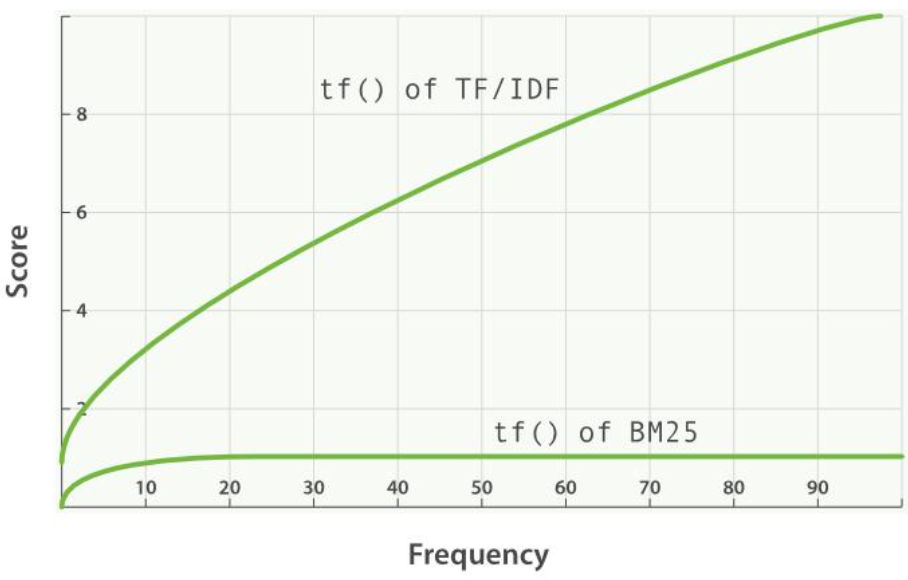

**BM25 = IDF × TF_saturation × Length_normalization**

$\text{BM25}(D, Q) = \sum_{i=1}^{n}\text{IDF}(q_i)\cdot\frac{f(q_i, D)\cdot (k_1 + 1)}{f(q_i, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}$

$\text{BM25}(D, Q) = \sum_{i=1}^{n} \log\left(\frac{N - n_i + 0.5}{n_i + 0.5}\right)
\cdot \frac{f(q_i, D)\cdot (k_1 + 1)} {f(q_i, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}$

- $D$: Document.
- $Q$: Query.
- $q_i$: The $i$-th query term in $Q$.
- $n$: The number of query terms in $Q$.
- $\text{IDF}(q_i)$: The inverse document frequency of query term $q_i$.
- $N$: The total number of documents in the collection.
- $n_i$: The number of documents that contain query term $q_i$.
- $|D|$: The length of document $D$.
- $\text{avgdl}$: The average document length in the collection.
- $k_1$: A hyperparameter controlling term frequency saturation. A common value is around $1.2$ to $2.0$.
- $b$: A hyperparameter controlling document length normalization. A common value is $0.75$.

| Aspect          | TF-IDF        | BM25                             |
| --------------- | ------------- | -------------------------------- |
| TF behavior     | Linear growth | Saturation (diminishing returns) |
| Length handling | Weak/simple   | Explicit normalization           |
| IDF             | Standard      | Smoothed                         |
| Performance     | Baseline      | Stronger retrieval model         |
| Usage           | Simple tasks  | Industrial search systems        |

<details>
<summary>Python Implementation</summary>
    
```python
import math
from collections import Counter, defaultdict


class BM25:
    def __init__(self, corpus, k1=1.5, b=0.75):
        """
        corpus: list[list[str]]
        Example:
        [
            ["this", "is", "a", "document"],
            ["this", "document", "is", "about", "nlp"]
        ]
        """
        self.corpus = corpus
        self.k1 = k1
        self.b = b
        self.N = len(corpus)
        self.doc_len = [len(doc) for doc in corpus]
        self.avgdl = sum(self.doc_len) / self.N

        self.doc_freq = defaultdict(int)
        self.term_freqs = []

        for doc in corpus:
            tf = Counter(doc)
            self.term_freqs.append(tf)

            for term in tf:
                self.doc_freq[term] += 1

    def idf(self, term):
        n_i = self.doc_freq.get(term, 0)

        return math.log((self.N - n_i + 0.5) / (n_i + 0.5) + 1)

    def score(self, query, doc_index):
        score = 0.0
        doc_tf = self.term_freqs[doc_index]
        doc_len = self.doc_len[doc_index]

        for term in query:
            f = doc_tf.get(term, 0)
            if f == 0:
                continue

            numerator = f * (self.k1 + 1)
            denominator = f + self.k1 * (
                1 - self.b + self.b * doc_len / self.avgdl
            )

            score += self.idf(term) * numerator / denominator

        return score

    def rank(self, query):
        scores = []

        for i in range(self.N):
            scores.append((i, self.score(query, i)))

        return sorted(scores, key=lambda x: x[1], reverse=True)

corpus = [
    "machine learning is useful",
    "deep learning is a part of machine learning",
    "natural language processing uses machine learning",
    "cooking recipes and food"
]

tokenized_corpus = [doc.lower().split() for doc in corpus]

bm25 = BM25(tokenized_corpus)

query = "machine learning"
tokenized_query = query.lower().split()

results = bm25.rank(tokenized_query)

for doc_id, score in results:
    print(score, corpus[doc_id])
```
</details>

<details>
<summary>Python rank-bm25 Implementation</summary>

```python
from rank_bm25 import BM25Okapi

corpus = [
    "machine learning is useful",
    "deep learning is a part of machine learning",
    "natural language processing uses machine learning",
    "cooking recipes and food"
]

tokenized_corpus = [doc.lower().split() for doc in corpus]

bm25 = BM25Okapi(tokenized_corpus)

query = "machine learning"
tokenized_query = query.lower().split()

scores = bm25.get_scores(tokenized_query)
ranked_docs = sorted(
    enumerate(scores),
    key=lambda x: x[1],
    reverse=True
)

for doc_id, score in ranked_docs:
    print(score, corpus[doc_id])

top_docs = bm25.get_top_n(tokenized_query, corpus, n=3)

for doc in top_docs:
    print(doc)
```
</details>

#### **Vector Similarity**

After converting text into vector representations (such as BoW or TF-IDF), we often need to measure how similar two documents are. This is done by computing the similarity between their vector representations. Two common methods for measuring vector similarity are **Dot Product** and **Cosine Similarity**.

##### Dot Product

The **dot product** measures the similarity between two vectors by multiplying corresponding elements and summing the results.

For two vectors:

$$
\mathbf{A} = (a_1, a_2, ..., a_n)
$$

$$
\mathbf{B} = (b_1, b_2, ..., b_n)
$$

the dot product is defined as:

$$
A \cdot B = \sum_{i=1}^{n} a_i b_i
$$

If two document vectors share many words with large values, the dot product will be larger. However, the dot product is affected by the **length of the vectors**.  
Longer documents often produce larger values even if the documents are not very similar.


##### Cosine Similarity

**Cosine similarity** is one of the most widely used similarity measures in NLP. Instead of comparing raw vector values, it measures the **angle between two vectors**. The cosine similarity between two vectors is defined as:

$$
\cos(\theta) =
\frac{A \cdot B}{||A|| \, ||B||}
$$

where:

- A.B is the dot product of the vectors
- ||A|| and ||B|| are the magnitudes (lengths) of the vectors

The value of cosine similarity ranges from:

- **1** → vectors are identical
- **0** → vectors are orthogonal (no similarity)
- **-1** → vectors are opposite

Because cosine similarity normalizes vector length, it works well for comparing documents of different sizes. For this reason, it is widely used in **information retrieval, document clustering, and text similarity tasks**.

### **Distributed Representation** (Word Embedding/Prediction Based)

#### **Word2Vec**
##### **CBOW**
##### **Skip-gram**
#### GloVe
#### Fast Text
#### Word Embedding Evaluation
### Contextual Embedding
#### ELMo (Based on LSTM)
#### BERT (Based on Transformer)
#### GPT

## **Tokenisation**

## **Modeling in NLP**
### Linear Models
### Non-Linear Models
### Sequence Models
#### Recurrent Neural Networks
### Attention & Transformers

## **Training & Optimization**

## **Evaluation in NLP**

## **Chanllenges**

## **NLP Tasks**
### Sequence Labeling
#### Name Entity Recognition(NER)
#### POS Tagging
#### Word Segmentation
### Classification
#### Sentiment Analysis
#### Intent Detection
#### Topic Classification
### Sentence Relationship
#### Semantic Textual Similarity(STS)
#### Natural Language Inference(NLI) / Recongnizing Textual Entailment(RTE)
### **Seq2Seq / Generation**
#### Machine Translation
#### Summarization
### Information Extraction

## **Modern NLP Systems**